<a href="https://colab.research.google.com/github/Adarsh230305/Data_Science/blob/main/K_Mean_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as numpy
from  sklearn.cluster import KMeans

In [2]:
X, y = make_blobs(n_samples=500, centers=3, n_features=2,random_state=0)

In [6]:
df=pd.DataFrame(X,columns=["Feature1","Feature2"])
df

,Feature1,Feature2
0,1.103182,4.705777
1,-1.932846,3.642251
2,-2.034422,1.866002
3,1.616402,2.686831
4,-0.960010,4.492566
...,...,...
495,2.660388,1.793220
496,2.875589,2.257612
497,2.826673,1.927102
498,-0.094483,5.358239


In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [35]:
Inertia=[]
K_range=range(1,11) # k_values
for k in K_range:
 K_meansC=KMeans(n_clusters=k, random_state=42)
 K_meansC.fit(x_scaled)
 Inertia.append(K_meansC.inertia_)

In [36]:
Inertia

[1000.000000000001,
 495.6316091067144,
 283.2247279740127,
 237.82492150970063,
 198.5853257280399,
 162.24890717983118,
 146.48056904115035,
 130.10847502202907,
 115.11998163900377,
 100.68643707171462]

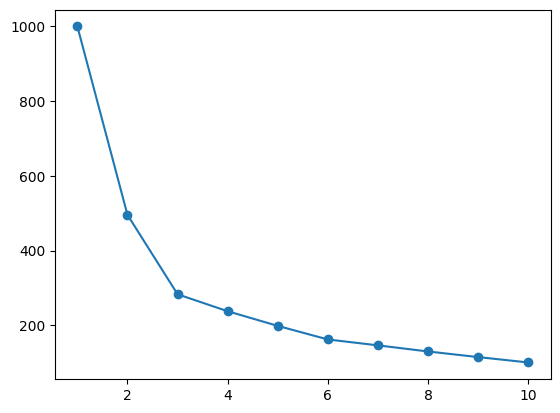

In [38]:
plt.plot(K_range,Inertia,marker='o')

In [46]:
# from above diagram we can confirm k=3 is best
K_means_final=KMeans(n_clusters=3, random_state=42)
cluster_labels=K_means_final.fit_predict(x_scaled)
df['Cluster']=cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

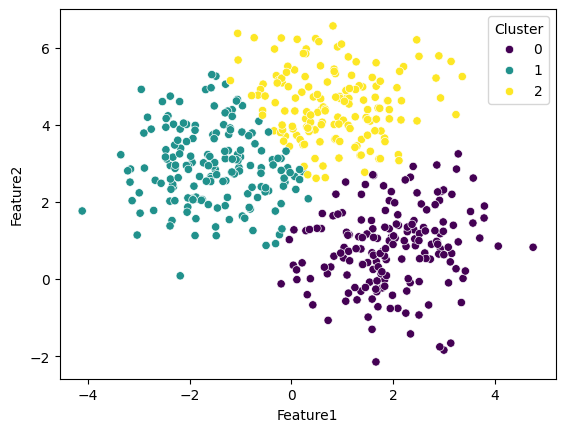

In [47]:
sns.scatterplot(x=df['Feature1'],y=df['Feature2'],hue=df['Cluster'],palette='viridis')